<a href="https://colab.research.google.com/github/Shokoul/ECE662-Project1/blob/main/ECE662Project1Task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

# -------------------------
# Device
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -------------------------
# Custom transform for averaging SVHN channels
# -------------------------
class AverageChannels:
    def __call__(self, img_tensor):
        # img_tensor shape: [3, H, W]
        return img_tensor.mean(dim=0, keepdim=True)

# -------------------------
# Transforms
# Resize to 224x224 for AlexNet
# -------------------------
mnist_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

svhn_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    AverageChannels(),   # average RGB -> grayscale
    transforms.Normalize((0.5,), (0.5,))
])

# -------------------------
# Datasets
# -------------------------
mnist_train = datasets.MNIST(root="./data", train=True, download=True, transform=mnist_transform)
mnist_test = datasets.MNIST(root="./data", train=False, download=True, transform=mnist_transform)
svhn_test = datasets.SVHN(root="./data", split='test', download=True, transform=svhn_transform)

train_loader = DataLoader(mnist_train, batch_size=64, shuffle=True, num_workers=2)
mnist_test_loader = DataLoader(mnist_test, batch_size=64, shuffle=False, num_workers=2)
svhn_test_loader = DataLoader(svhn_test, batch_size=64, shuffle=False, num_workers=2)

# -------------------------
# AlexNet model
# -------------------------
model = models.alexnet(weights=None)

# First conv: 1 input channel instead of 3
model.features[0] = nn.Conv2d(
    in_channels=1,
    out_channels=64,
    kernel_size=11,
    stride=4,
    padding=2
)

# Final classifier: 10 classes
model.classifier[6] = nn.Linear(model.classifier[6].in_features, 10)

model = model.to(device)

# -------------------------
# Loss and optimizer
# -------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# -------------------------
# Training function
# -------------------------
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    return epoch_loss, epoch_acc

# -------------------------
# Evaluation function
# -------------------------
def evaluate(model, loader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100.0 * correct / total

# -------------------------
# Train
# -------------------------
num_epochs = 5 #10 # 20

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    mnist_acc = evaluate(model, mnist_test_loader, device)
    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"MNIST Test Acc: {mnist_acc:.2f}%")

# -------------------------
# Test on SVHN
# -------------------------
svhn_acc = evaluate(model, svhn_test_loader, device)
print(f"\nBaseline test accuracy on SVHN (no adaptation): {svhn_acc:.2f}%")

Using device: cuda
Epoch [1/5] | Train Loss: 0.2646 | Train Acc: 91.43% | MNIST Test Acc: 98.45%
Epoch [2/5] | Train Loss: 0.0926 | Train Acc: 97.38% | MNIST Test Acc: 98.71%
Epoch [3/5] | Train Loss: 0.0800 | Train Acc: 97.84% | MNIST Test Acc: 98.82%
Epoch [4/5] | Train Loss: 0.0661 | Train Acc: 98.11% | MNIST Test Acc: 98.77%
Epoch [5/5] | Train Loss: 0.0609 | Train Acc: 98.34% | MNIST Test Acc: 99.23%

Baseline test accuracy on SVHN (no adaptation): 21.78%


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

# -------------------------
# Device
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -------------------------
# Transforms
# AlexNet expects larger images, so we resize to 32x32.
# MNIST is already 1-channel.
# SVHN is 3-channel, so we convert to grayscale by averaging channels.
# -------------------------
mnist_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    # normalize for grayscale
    transforms.Normalize((0.5,), (0.5,))
])

svhn_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.Grayscale(num_output_channels=1),   # averages RGB -> 1 channel
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# -------------------------
# Datasets
# -------------------------
mnist_train = datasets.MNIST(root="./data", train=True, download=True, transform=mnist_transform)
mnist_test  = datasets.MNIST(root="./data", train=False, download=True, transform=mnist_transform)

svhn_test = datasets.SVHN(root="./data", split='test', download=True, transform=svhn_transform)

train_loader = DataLoader(mnist_train, batch_size=128, shuffle=True, num_workers=2)
mnist_test_loader = DataLoader(mnist_test, batch_size=128, shuffle=False, num_workers=2)
svhn_test_loader = DataLoader(svhn_test, batch_size=128, shuffle=False, num_workers=2)

# -------------------------
# AlexNet modified for 1-channel input and 10 classes
# Adapted for 32x32 input images
# -------------------------
class CustomAlexNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=5, stride=1, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), # 32 -> 16

            nn.Conv2d(64, 192, kernel_size=5, stride=1, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), # 16 -> 8

            nn.Conv2d(192, 384, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), # 8 -> 4
        )
        self.avgpool = nn.AdaptiveAvgPool2d((4, 4))
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256 * 4 * 4, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

model = CustomAlexNet(num_classes=10).to(device)

# -------------------------
# Loss and optimizer
# -------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# -------------------------
# Training
# -------------------------
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    return epoch_loss, epoch_acc

# -------------------------
# Evaluation
# -------------------------
def evaluate(model, loader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100.0 * correct / total

# -------------------------
# Run training
# -------------------------
num_epochs = 10

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    mnist_acc = evaluate(model, mnist_test_loader, device)
    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"MNIST Test Acc: {mnist_acc:.2f}%")

# -------------------------
# Baseline domain-shift evaluation
# -------------------------
svhn_acc = evaluate(model, svhn_test_loader, device)
print(f"\nBaseline test accuracy on SVHN (no adaptation): {svhn_acc:.2f}%")

Using device: cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 20.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 497kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.58MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.4MB/s]
100%|██████████| 64.3M/64.3M [00:01<00:00, 54.8MB/s]


NameError: name 'mnist_test_loader' is not defined

Using device: cuda


100%|██████████| 182M/182M [00:01<00:00, 94.0MB/s]



Running experiment with K = 2
[Source][Epoch 1/10] Loss=0.5238, TrainAcc=81.83%, MNIST Test=95.35%
[Source][Epoch 2/10] Loss=0.1294, TrainAcc=96.06%, MNIST Test=97.81%
[Source][Epoch 3/10] Loss=0.0889, TrainAcc=97.28%, MNIST Test=98.25%
[Source][Epoch 4/10] Loss=0.0730, TrainAcc=97.70%, MNIST Test=98.30%
[Source][Epoch 5/10] Loss=0.0598, TrainAcc=98.14%, MNIST Test=98.73%
[Source][Epoch 6/10] Loss=0.0556, TrainAcc=98.31%, MNIST Test=98.72%
[Source][Epoch 7/10] Loss=0.0511, TrainAcc=98.41%, MNIST Test=98.94%
[Source][Epoch 8/10] Loss=0.0402, TrainAcc=98.77%, MNIST Test=98.89%
[Source][Epoch 9/10] Loss=0.0392, TrainAcc=98.78%, MNIST Test=98.90%
[Source][Epoch 10/10] Loss=0.0369, TrainAcc=98.82%, MNIST Test=99.09%
SVHN Test Accuracy before adaptation: 21.78%
[Target Adapt][Epoch 1/5] Loss=2.0033, TrainAcc=31.54%, SVHN Test=40.84%
[Target Adapt][Epoch 2/5] Loss=1.9145, TrainAcc=34.81%, SVHN Test=40.86%
[Target Adapt][Epoch 3/5] Loss=1.8884, TrainAcc=35.68%, SVHN Test=42.29%
[Target Adapt]

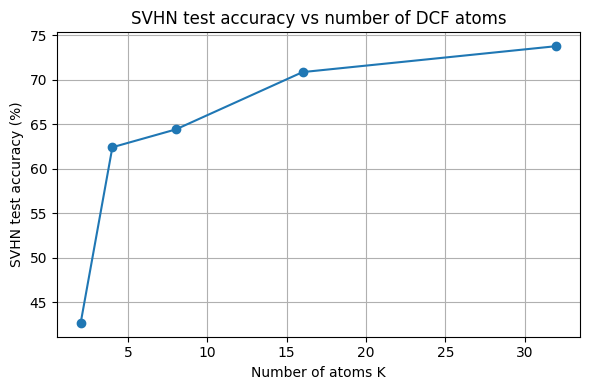

Best K = 32, SVHN test accuracy = 73.79%


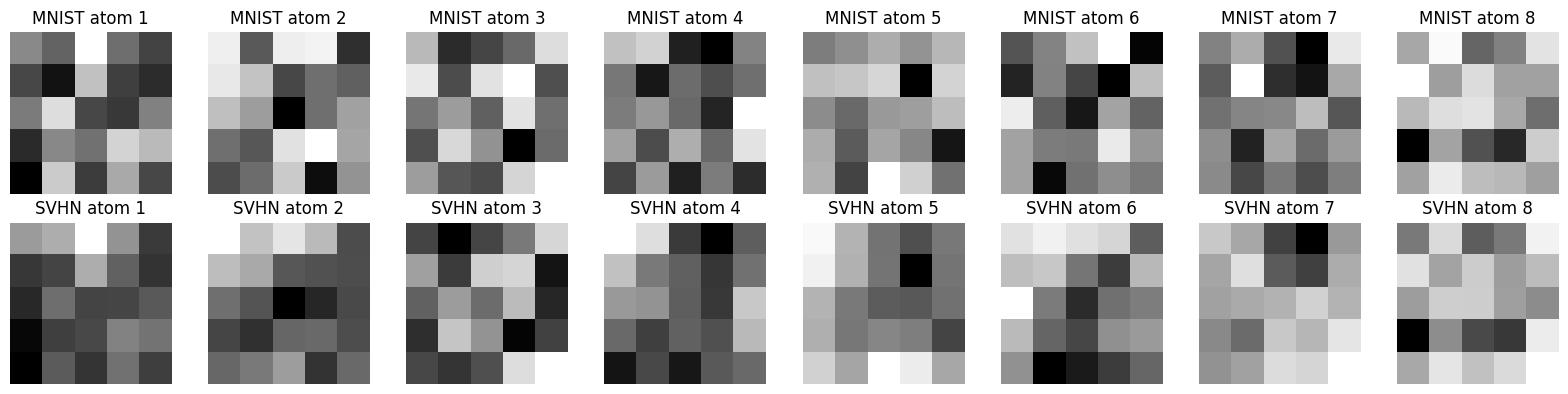

In [3]:
import copy
import math
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# ============================================================
# Device
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ============================================================
# Data
# Both MNIST and SVHN are converted to 1-channel, size 32x32
# ============================================================
class AverageChannels:
    def __call__(self, x):
        # x: [3, H, W]
        return x.mean(dim=0, keepdim=True)

mnist_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

svhn_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    AverageChannels(),   # average 3 channels -> 1 channel
    transforms.Normalize((0.5,), (0.5,))
])

mnist_train = datasets.MNIST(root="./data", train=True, download=True, transform=mnist_transform)
mnist_test  = datasets.MNIST(root="./data", train=False, download=True, transform=mnist_transform)

svhn_train = datasets.SVHN(root="./data", split="train", download=True, transform=svhn_transform)
svhn_test  = datasets.SVHN(root="./data", split="test",  download=True, transform=svhn_transform)

batch_size = 128
mnist_train_loader = DataLoader(mnist_train, batch_size=batch_size, shuffle=True, num_workers=2)
mnist_test_loader  = DataLoader(mnist_test,  batch_size=batch_size, shuffle=False, num_workers=2)
svhn_train_loader  = DataLoader(svhn_train,  batch_size=batch_size, shuffle=True, num_workers=2)
svhn_test_loader   = DataLoader(svhn_test,   batch_size=batch_size, shuffle=False, num_workers=2)

# ============================================================
# DCF Layer
# W = sum_k a[:,:,k] * Psi_k
#
# Shared coefficients: coeff [out_channels, in_channels, K]
# Domain-specific atoms:
#   atoms_source [K, kh, kw]
#   atoms_target [K, kh, kw]
#
# During forward, choose source or target atoms depending on domain.
# ============================================================
class DCFConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size,
                 K, stride=1, padding=0, bias=True):
        super().__init__()

        if isinstance(kernel_size, int):
            kh, kw = kernel_size, kernel_size
        else:
            kh, kw = kernel_size

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kh = kh
        self.kw = kw
        self.K = K
        self.stride = stride
        self.padding = padding

        # Shared coefficients: a_{o,i,k}
        self.coeff = nn.Parameter(torch.empty(out_channels, in_channels, K))

        # Domain-specific atoms
        self.atoms_source = nn.Parameter(torch.empty(K, kh, kw))
        self.atoms_target = nn.Parameter(torch.empty(K, kh, kw))

        if bias:
            self.bias = nn.Parameter(torch.zeros(out_channels))
        else:
            self.bias = None

        self.reset_parameters()

    def reset_parameters(self):
        nn.init.normal_(self.coeff, mean=0.0, std=0.05)

        # initialize atoms with small random patterns
        nn.init.normal_(self.atoms_source, mean=0.0, std=0.1)
        nn.init.normal_(self.atoms_target, mean=0.0, std=0.1)

        if self.bias is not None:
            nn.init.zeros_(self.bias)

    def build_weight(self, domain="source"):
        if domain == "source":
            atoms = self.atoms_source
        elif domain == "target":
            atoms = self.atoms_target
        else:
            raise ValueError("domain must be 'source' or 'target'")

        # coeff: [O, I, K]
        # atoms: [K, kh, kw]
        # output W: [O, I, kh, kw]
        W = torch.einsum("oik,khw->oihw", self.coeff, atoms)
        return W

    def forward(self, x, domain="source"):
        W = self.build_weight(domain)
        return F.conv2d(x, W, self.bias, stride=self.stride, padding=self.padding)

# ============================================================
# AlexNet-style feature extractor for 32x32 images
# Replace all conv layers with DCFConv2d
# ============================================================
class DCFAlexNet32(nn.Module):
    def __init__(self, K=8, num_classes=10):
        super().__init__()

        self.conv1 = DCFConv2d(1,   64, kernel_size=5, K=K, stride=1, padding=2)
        self.conv2 = DCFConv2d(64, 192, kernel_size=5, K=K, stride=1, padding=2)
        self.conv3 = DCFConv2d(192, 384, kernel_size=3, K=K, stride=1, padding=1)
        self.conv4 = DCFConv2d(384, 256, kernel_size=3, K=K, stride=1, padding=1)
        self.conv5 = DCFConv2d(256, 256, kernel_size=3, K=K, stride=1, padding=1)

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256 * 4 * 4, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, num_classes)
        )

    def forward(self, x, domain="source"):
        x = F.relu(self.conv1(x, domain))
        x = F.max_pool2d(x, 2)   # 32 -> 16

        x = F.relu(self.conv2(x, domain))
        x = F.max_pool2d(x, 2)   # 16 -> 8

        x = F.relu(self.conv3(x, domain))
        x = F.relu(self.conv4(x, domain))
        x = F.relu(self.conv5(x, domain))
        x = F.max_pool2d(x, 2)   # 8 -> 4

        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

    def dcf_layers(self):
        return [self.conv1, self.conv2, self.conv3, self.conv4, self.conv5]

# ============================================================
# Helper functions
# ============================================================
def evaluate(model, loader, domain="source"):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            logits = model(x, domain=domain)
            pred = logits.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)

    return 100.0 * correct / total

def train_epoch(model, loader, optimizer, criterion, domain="source"):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits = model(x, domain=domain)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * y.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)

    return running_loss / total, 100.0 * correct / total

# ============================================================
# Parameter selection:
# - source training: train shared coeffs + source atoms + classifier
# - target adaptation: freeze coeffs + source atoms + classifier
#                      train target atoms only
# ============================================================
def set_train_mode_source(model):
    for p in model.parameters():
        p.requires_grad = False

    # train shared coeffs and source atoms
    for layer in model.dcf_layers():
        layer.coeff.requires_grad = True
        layer.atoms_source.requires_grad = True
        layer.atoms_target.requires_grad = False
        if layer.bias is not None:
            layer.bias.requires_grad = True

    # classifier also learned on source
    for p in model.classifier.parameters():
        p.requires_grad = True

def set_train_mode_target_atoms_only(model):
    for p in model.parameters():
        p.requires_grad = False

    # adapt only target atoms
    for layer in model.dcf_layers():
        layer.atoms_target.requires_grad = True

def get_trainable_params(model):
    return [p for p in model.parameters() if p.requires_grad]

# ============================================================
# Optional: initialize target atoms from learned source atoms
# ============================================================
def copy_source_atoms_to_target(model):
    for layer in model.dcf_layers():
        with torch.no_grad():
            layer.atoms_target.copy_(layer.atoms_source)

# ============================================================
# Visualization of atoms
# Show first N atoms from first DCF layer
# ============================================================
def plot_atoms(model, save_path=None, layer_idx=0, max_atoms=8):
    layers = model.dcf_layers()
    layer = layers[layer_idx]

    src_atoms = layer.atoms_source.detach().cpu().numpy()
    tgt_atoms = layer.atoms_target.detach().cpu().numpy()

    n = min(max_atoms, src_atoms.shape[0])

    fig, axes = plt.subplots(2, n, figsize=(2*n, 4))
    for i in range(n):
        axes[0, i].imshow(src_atoms[i], cmap="gray")
        axes[0, i].set_title(f"MNIST atom {i+1}")
        axes[0, i].axis("off")

        axes[1, i].imshow(tgt_atoms[i], cmap="gray")
        axes[1, i].set_title(f"SVHN atom {i+1}")
        axes[1, i].axis("off")

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

# ============================================================
# One full experiment for a given K
# ============================================================
def run_experiment(K=8, source_epochs=10, target_epochs=5, lr_source=1e-3, lr_target=1e-3):
    print(f"\n==============================")
    print(f"Running experiment with K = {K}")
    print(f"==============================")

    model = DCFAlexNet32(K=K, num_classes=10).to(device)
    criterion = nn.CrossEntropyLoss()

    # --------------------------
    # Stage 1: source training on MNIST
    # learn shared coeffs + source atoms + classifier
    # --------------------------
    set_train_mode_source(model)
    optimizer_source = optim.Adam(get_trainable_params(model), lr=lr_source)

    for epoch in range(source_epochs):
        loss, acc = train_epoch(model, mnist_train_loader, optimizer_source, criterion, domain="source")
        mnist_acc = evaluate(model, mnist_test_loader, domain="source")
        print(f"[Source][Epoch {epoch+1}/{source_epochs}] "
              f"Loss={loss:.4f}, TrainAcc={acc:.2f}%, MNIST Test={mnist_acc:.2f}%")

    # Baseline cross-domain before adaptation
    # initialize target atoms from source atoms first
    copy_source_atoms_to_target(model)
    svhn_before = evaluate(model, svhn_test_loader, domain="target")
    print(f"SVHN Test Accuracy before adaptation: {svhn_before:.2f}%")

    # --------------------------
    # Stage 2: target adaptation on SVHN
    # freeze shared coeffs, adapt target atoms only
    # --------------------------
    set_train_mode_target_atoms_only(model)
    optimizer_target = optim.Adam(get_trainable_params(model), lr=lr_target)

    for epoch in range(target_epochs):
        loss, acc = train_epoch(model, svhn_train_loader, optimizer_target, criterion, domain="target")
        svhn_acc = evaluate(model, svhn_test_loader, domain="target")
        print(f"[Target Adapt][Epoch {epoch+1}/{target_epochs}] "
              f"Loss={loss:.4f}, TrainAcc={acc:.2f}%, SVHN Test={svhn_acc:.2f}%")

    final_svhn = evaluate(model, svhn_test_loader, domain="target")
    print(f"Final SVHN Test Accuracy after adaptation: {final_svhn:.2f}%")

    return model, final_svhn

# ============================================================
# Sweep over number of atoms K
# ============================================================
K_values = [2, 4, 8, 16, 32]
svhn_accs = []
saved_models = {}

for K in K_values:
    model, acc = run_experiment(
        K=K,
        source_epochs=10,     #20
        target_epochs=5,  #10 #20
        lr_source=1e-3,
        lr_target=1e-3
    )
    svhn_accs.append(acc)
    saved_models[K] = copy.deepcopy(model).cpu()

# ============================================================
# Plot accuracy vs K
# ============================================================
plt.figure(figsize=(6, 4))
plt.plot(K_values, svhn_accs, marker='o')
plt.xlabel("Number of atoms K")
plt.ylabel("SVHN test accuracy (%)")
plt.title("SVHN test accuracy vs number of DCF atoms")
plt.grid(True)
plt.tight_layout()
plt.savefig("svhn_accuracy_vs_K.png", dpi=200, bbox_inches="tight")
plt.show()

# ============================================================
# Visualize atoms for one chosen K
# ============================================================
best_idx = int(np.argmax(svhn_accs))
best_K = K_values[best_idx]
best_model = saved_models[best_K].to(device)

print(f"Best K = {best_K}, SVHN test accuracy = {svhn_accs[best_idx]:.2f}%")
plot_atoms(best_model, save_path="atoms_mnist_vs_svhn.png", layer_idx=0, max_atoms=min(best_K, 8))